In [190]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

In [192]:

caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\df_intermediario.parquet"

df_intermediario = pd.read_parquet(caminho_parquet)

In [193]:
df_intermediario['RADIAÇÃO PRIMEIRA HORA ANTERIOR'] = df_intermediario['RADIAÇÃO PRIMEIRA HORA ANTERIOR'].fillna(-9999.000000)

df_intermediario['RADIAÇÃO SEGUNDA HORA ANTERIOR'] = df_intermediario['RADIAÇÃO SEGUNDA HORA ANTERIOR'].fillna(-9999.000000)

df_intermediario['RADIAÇÃO TERCEIRA HORA ANTERIOR'] = df_intermediario['RADIAÇÃO TERCEIRA HORA ANTERIOR'].fillna(-9999.000000)


In [196]:
df_intermediario['RADIAÇÃO PRIMEIRA HORA ANTERIOR'].describe()

count    490354.000000
mean      -2988.279947
std        5436.428598
min       -9999.000000
25%       -9999.000000
50%          19.300000
75%        1196.500000
max        5310.000000
Name: RADIAÇÃO PRIMEIRA HORA ANTERIOR, dtype: float64

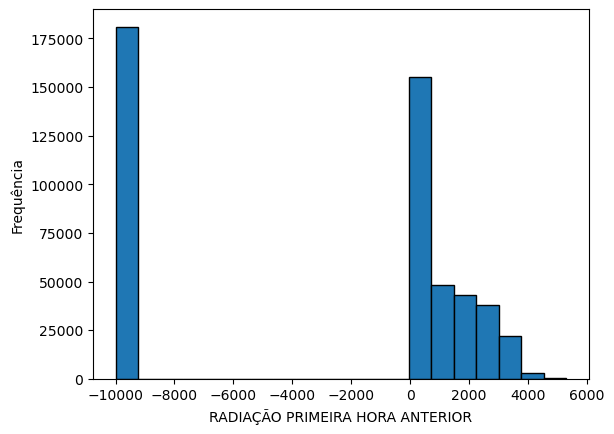

In [198]:
coluna = "RADIAÇÃO PRIMEIRA HORA ANTERIOR"

plt.hist(df_intermediario[coluna], bins= 20, edgecolor="black")
plt.xlabel("RADIAÇÃO PRIMEIRA HORA ANTERIOR")
plt.ylabel("Frequência")
plt.title("")
plt.show()


In [200]:
df2 = df_intermediario[df_intermediario['RADIAÇÃO PRIMEIRA HORA ANTERIOR'] != -9999.000000]

In [202]:
df2['RADIAÇÃO PRIMEIRA HORA ANTERIOR'].describe()

count    309401.000000
mean       1111.935714
std        1132.481426
min           0.000000
25%          53.900000
50%         711.800000
75%        2003.800000
max        5310.000000
Name: RADIAÇÃO PRIMEIRA HORA ANTERIOR, dtype: float64

In [204]:
df2['RADIAÇÃO PRIMEIRA HORA ANTERIOR'].isna().sum()


0

In [206]:
X = df2[['RADIAÇÃO PRIMEIRA HORA ANTERIOR']]

kmeans = KMeans(n_clusters = 3, random_state= 10)

df2['RADIAÇÃO PRIMEIRA HORA ANTERIOR CLUSTER K MEANS'] = kmeans.fit_predict(X)

# Obter os centróides dos clusters 
centroids = kmeans.cluster_centers_

print("Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS': ", centroids)



Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS':  [[ 214.97436691]
 [1543.0262053 ]
 [2922.93826452]]


C:\Users\Pichau\AppData\Local\Temp\ipykernel_13272\4202236542.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['RADIAÇÃO PRIMEIRA HORA ANTERIOR CLUSTER K MEANS'] = kmeans.fit_predict(X)


In [208]:
dados = df2[(df2['RADIAÇÃO PRIMEIRA HORA ANTERIOR'] >= 0)]

percentis = np.arange(0, 101, 1)

valores_percentis = np.percentile(dados['RADIAÇÃO PRIMEIRA HORA ANTERIOR'], percentis)

df_percentis = pd.DataFrame({'Percentis de RADIAÇÃO PRIMEIRA HORA ANTERIOR': percentis, 'Valor': valores_percentis})
# pd.set_option('display.max_rows', None)

df_percentis


,Percentis de RADIAÇÃO PRIMEIRA HORA ANTERIOR,Valor
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0
...,...,...
96,96,3405.7
97,97,3515.7
98,98,3635.8
99,99,3778.0


In [210]:
########################################################################################

In [212]:
centroides =  np.array([214.97436691, 1543.0262053, 2922.93826452])

In [224]:
def atribuir_cluster(valor):
    if valor == -9999.000000:
        return -99
    else:
        distancias = np.abs(centroides - valor)  # como é 1D, usar valor absoluto já resolve
        return np.argmin(distancias)  # retorna o índice do centro mais próximo

# Aplica a função à nova coluna
df_intermediario['RADIAÇÃO PRIMEIRA HORA ANTERIOR CLUSTER K MEANS'] = df_intermediario['RADIAÇÃO PRIMEIRA HORA ANTERIOR'].apply(atribuir_cluster)]
df_intermediario['RADIAÇÃO SEGUNDA HORA ANTERIOR CLUSTER K MEANS'] = df_intermediario['RADIAÇÃO  SEGUNDA HORA ANTERIOR'].apply(atribuir_cluster)
df_intermediario['RADIAÇÃO TERCEIRA HORA ANTERIOR CLUSTER K MEANS'] = df_intermediario['RADIAÇÃO TERCEIRA HORA ANTERIOR'].apply(atribuir_cluster)

In [226]:
df_intermediario['RADIAÇÃO PRIMEIRA HORA ANTERIOR CLUSTER K MEANS - ROTULOS'] = df_intermediario[
    'RADIAÇÃO PRIMEIRA HORA ANTERIOR CLUSTER K MEANS'
].map({
   -99: 'Sem medição',
    0: 'baixo ou nenhuma 0',      # 214.97436691 Cluster com centróide 
    1: 'medio',     # Cluster com 1543.0262053
    2: 'alto'      # 2922.93826452 Cluster com centróide 
})

df_intermediario['RADIAÇÃO SEGUNDA HORA ANTERIOR CLUSTER K MEANS - ROTULOS'] = df_intermediario[
    'RADIAÇÃO SEGUNDA HORA ANTERIOR CLUSTER K MEANS'
].map({
   -99: 'Sem medição',
    0: 'baixo ou nenhuma 0',      # 214.97436691 Cluster com centróide 
    1: 'medio',     # Cluster com 1543.0262053
    2: 'alto'      # 2922.93826452 Cluster com centróide 
})


df_intermediario['RADIAÇÃO TERCEIRA HORA ANTERIOR CLUSTER K MEANS - ROTULOS'] = df_intermediario[
    'RADIAÇÃO TERCEIRA HORA ANTERIOR CLUSTER K MEANS'
].map({
   -99: 'Sem medição',
    0: 'baixo ou nenhuma 0',      # 214.97436691 Cluster com centróide 
    1: 'medio',     # Cluster com 1543.0262053
    2: 'alto'      # 2922.93826452 Cluster com centróide 
})


In [228]:
df_intermediario[['RADIAÇÃO PRIMEIRA HORA ANTERIOR', 
                  'RADIAÇÃO PRIMEIRA HORA ANTERIOR CLUSTER K MEANS',
                  'RADIAÇÃO PRIMEIRA HORA ANTERIOR CLUSTER K MEANS - ROTULOS'
                        ]]

,RADIAÇÃO PRIMEIRA HORA ANTERIOR,RADIAÇÃO PRIMEIRA HORA ANTERIOR CLUSTER K MEANS,RADIAÇÃO PRIMEIRA HORA ANTERIOR CLUSTER K MEANS - ROTULOS
0,-9999.0,-99,Sem medição
1,100.8,0,baixo ou nenhuma 0
2,-9999.0,-99,Sem medição
3,91.2,0,baixo ou nenhuma 0
4,141.0,0,baixo ou nenhuma 0
...,...,...,...
490349,2185.8,1,medio
490350,1413.8,1,medio
490351,657.2,0,baixo ou nenhuma 0
490352,214.5,0,baixo ou nenhuma 0


In [232]:
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\df_intermediario.parquet"


df_intermediario.to_parquet(caminho_parquet, index=False)